<a href="https://colab.research.google.com/github/paramita-pp/time-series-analysis/blob/main/Restaurant_Order_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Restaurant Orders Analysis**

Follow: https://www.youtube.com/watch?v=8VF4Br4T2wQ

We have two flat files to analyze: `orders.csv` and `menu_items.csv`. We need to use to answer the following questions.

1. What items drive the most and least revenue?
2. Which time periods have the highest and lowest revenue?

## Importing The Orders File

In [41]:
import pandas as pd

orders_df = pd.read_csv('https://raw.githubusercontent.com/paramita-pp/time-series-analysis/refs/heads/main/Restaurant%20Orders%20Analysis/Restaurant%2BOrders%2BCSV/order_details.csv',
                        parse_dates = ['order_date', 'order_time'])

orders_df.tail(10)

/tmp/ipython-input-1016287364.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders_df = pd.read_csv('https://raw.githubusercontent.com/paramita-pp/time-series-analysis/refs/heads/main/Restaurant%20Orders%20Analysis/Restaurant%2BOrders%2BCSV/order_details.csv',
/tmp/ipython-input-1016287364.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders_df = pd.read_csv('https://raw.githubusercontent.com/paramita-pp/time-series-analysis/refs/heads/main/Restaurant%20Orders%20Analysis/Restaurant%2BOrders%2BCSV/order_details.csv',


,order_details_id,order_id,order_date,order_time,item_id
12224,12225,5367,2023-03-31,2025-12-14 21:58:06,119.0
12225,12226,5368,2023-03-31,2025-12-14 21:58:47,101.0
12226,12227,5368,2023-03-31,2025-12-14 21:58:47,128.0
12227,12228,5368,2023-03-31,2025-12-14 21:58:47,113.0
12228,12229,5368,2023-03-31,2025-12-14 21:58:47,118.0
12229,12230,5369,2023-03-31,2025-12-14 22:05:04,109.0
12230,12231,5369,2023-03-31,2025-12-14 22:05:04,129.0
12231,12232,5369,2023-03-31,2025-12-14 22:05:04,120.0
12232,12233,5369,2023-03-31,2025-12-14 22:05:04,122.0
12233,12234,5370,2023-03-31,2025-12-14 22:15:48,122.0


In [42]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  datetime64[ns]
 3   order_time        12234 non-null  datetime64[ns]
 4   item_id           12097 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 478.0 KB


## Cleaning Missing Rows

Since we cannot do much in this analysis on missing item_id (unique item identifier), cannot fill item id.

We should highlight this problem to manager or relevant parties to check the root cause of this missing. It can be manual error or system error that needed to be fixed.

But nothing can do at the analysis level. For this case, we will drop first.

In [43]:
orders_df = orders_df.dropna()

## Joining Menu Items

In [44]:
menu_df = pd.read_csv('https://raw.githubusercontent.com/paramita-pp/time-series-analysis/refs/heads/main/Restaurant%20Orders%20Analysis/Restaurant%2BOrders%2BCSV/menu_items.csv')

menu_df.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [45]:
menu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   menu_item_id  32 non-null     int64  
 1   item_name     32 non-null     object 
 2   category      32 non-null     object 
 3   price         32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


In [46]:
order_items_df = orders_df.merge(menu_df, how = "left", left_on= "item_id", right_on = "menu_item_id").drop("menu_item_id", axis = 1)

order_items_df.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price
0,1,1,2023-01-01,2025-12-14 11:38:36,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,2025-12-14 11:57:40,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,2025-12-14 11:57:40,124.0,Spaghetti,Italian,14.50
3,4,2,2023-01-01,2025-12-14 11:57:40,117.0,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,2025-12-14 11:57:40,129.0,Mushroom Ravioli,Italian,15.50


## Add Tax & Total Revenue Columns

In [47]:
order_items_df["sales_tax"] = (order_items_df.price * 0.08).round(2)
order_items_df["total_revenue"] = order_items_df.price * order_items_df.sales_tax

order_items_df.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,sales_tax,total_revenue
0,1,1,2023-01-01,2025-12-14 11:38:36,109.0,Korean Beef Bowl,Asian,17.95,1.44,25.848
1,2,2,2023-01-01,2025-12-14 11:57:40,108.0,Tofu Pad Thai,Asian,14.50,1.16,16.820
2,3,2,2023-01-01,2025-12-14 11:57:40,124.0,Spaghetti,Italian,14.50,1.16,16.820
3,4,2,2023-01-01,2025-12-14 11:57:40,117.0,Chicken Burrito,Mexican,12.95,1.04,13.468
4,5,2,2023-01-01,2025-12-14 11:57:40,129.0,Mushroom Ravioli,Italian,15.50,1.24,19.220


In [48]:
order_items_df.describe()

,order_details_id,order_id,order_date,order_time,item_id,price,sales_tax,total_revenue
count,12097.000000,12097.000000,12097,12097,12097.000000,12097.000000,12097.000000,12097.000000
mean,6118.950897,2692.569149,2023-02-14 11:17:33.781929216,2025-12-14 16:22:19.455071744,115.202282,13.161767,1.055128,15.163180
min,1.000000,1.000000,2023-01-01 00:00:00,2025-12-14 10:50:46,101.000000,5.000000,0.400000,2.000000
25%,3064.000000,1353.000000,2023-01-23 00:00:00,2025-12-14 13:26:19,107.000000,10.500000,0.840000,8.820000
50%,6119.000000,2711.000000,2023-02-14 00:00:00,2025-12-14 16:30:20,114.000000,13.950000,1.120000,15.624000
75%,9175.000000,4020.000000,2023-03-09 00:00:00,2025-12-14 18:52:11,123.000000,16.500000,1.320000,21.780000
max,12234.000000,5370.000000,2023-03-31 00:00:00,2025-12-14 23:05:24,132.000000,19.950000,1.600000,31.920000
std,3531.337208,1545.826452,NaN,NaN,9.387580,3.986392,0.320078,7.867461


## Analyzing Best & Worst Selling Items

<Axes: ylabel='item_name'>

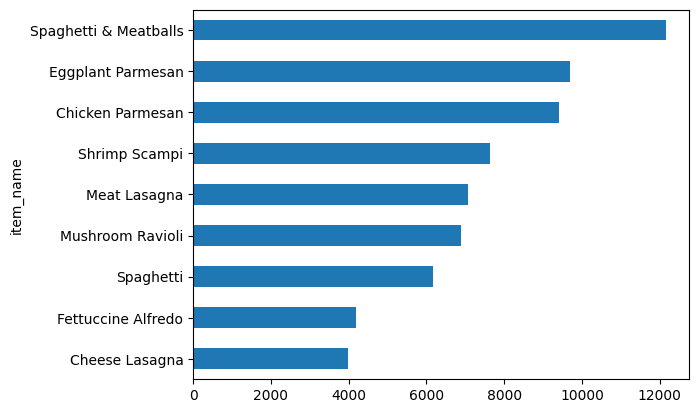

In [9]:
(order_items_df
    .query("category == 'Italian'")
    .groupby('item_name')
    ['total_revenue']
    .sum()
    .sort_values()
    .plot.barh()
)


## Analyzing Busiest Times

<Axes: xlabel='order_date'>

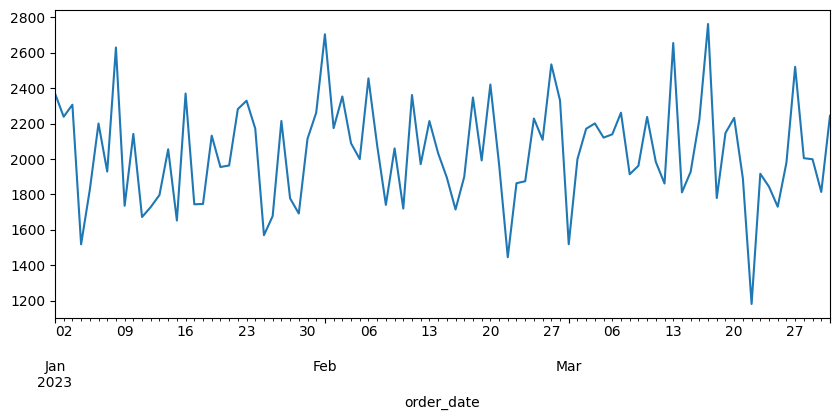

In [38]:
order_items_df \
    .set_index('order_date') \
    .resample('D')['total_revenue'] \
    .sum() \
    .plot(figsize=(10,4))


/tmp/ipython-input-3642494432.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['total_revenue'] \


<Axes: xlabel='order_date'>

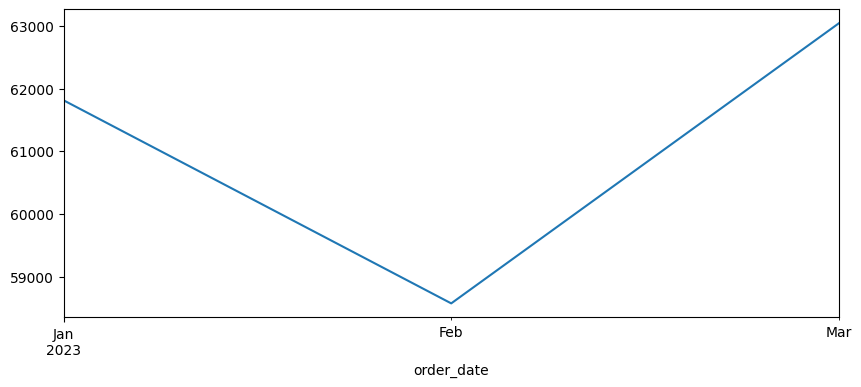

In [40]:
order_items_df \
    .set_index('order_date') \
    .resample('M')['total_revenue'] \
    .sum() \
    .plot(figsize=(10,4))


In [50]:
order_items_df['dayofweek'] = order_items_df.order_date.dt.dayofweek
order_items_df['hour'] = order_items_df.order_time.dt.hour

order_items_df.head()

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price,sales_tax,total_revenue,dayofweek,hour
0,1,1,2023-01-01,2025-12-14 11:38:36,109.0,Korean Beef Bowl,Asian,17.95,1.44,25.848,6,11
1,2,2,2023-01-01,2025-12-14 11:57:40,108.0,Tofu Pad Thai,Asian,14.50,1.16,16.820,6,11
2,3,2,2023-01-01,2025-12-14 11:57:40,124.0,Spaghetti,Italian,14.50,1.16,16.820,6,11
3,4,2,2023-01-01,2025-12-14 11:57:40,117.0,Chicken Burrito,Mexican,12.95,1.04,13.468,6,11
4,5,2,2023-01-01,2025-12-14 11:57:40,129.0,Mushroom Ravioli,Italian,15.50,1.24,19.220,6,11


<Axes: xlabel='dayofweek', ylabel='hour'>

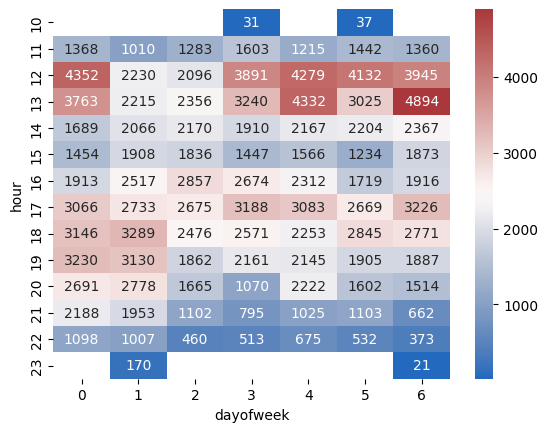

In [53]:
import seaborn as sns

sns.heatmap(
    order_items_df.pivot_table(
    index = 'hour',
    columns = 'dayofweek',
    values = 'total_revenue',
    aggfunc = 'sum'
    ).round(),
    annot = True,
    fmt = 'g',
    cmap ='vlag'
)